# HYCOM GOFS 3.1 Global Ocean Reanalysis — virtual Icechunk on Source Cooperative

Builds the [Icechunk](https://icechunk.io) store at
**`https://data.source.coop/ocean-icechunks/hycom/hycom-gofs-3pt1-reanalysis`** from the
[HYCOM GOFS 3.1 reanalysis on AWS Open Data](https://registry.opendata.aws/hycom-gofs-3pt1-reanalysis/)
(GLBv0.08 expt_53.X, 3-hourly, 1994–2015): 63,341 NetCDF files, 306 TB.

The store is **virtual** — Zarr metadata and byte-range references, about 85 MB — and the
arrays stay in the HYCOM bucket. Three things make this archive different from the usual
virtual build, and `hycom_virtual.py` is where they are handled:

1. **The files are uncompressed and unchunked** NetCDF-3: each 4-D variable is one 1.17 GB
   byte range. Because nothing is compressed, a depth level is a contiguous 29 MB slice of
   it, so the store references **one chunk per level** without rewriting anything.
2. **No file is parsed.** Each file's header is read with one 67 kB ranged GET, every file is
   checked against the others, and the references are computed. That is why this build takes
   minutes where a parser pass over 63,341 files of 4.8 GB would take days.
3. **Offsets come from each file's own header.** The archive has two header layouts, 40 bytes
   apart, mixed within experiments; a template built from one file misplaces the data in the
   other kind by 20 grid cells.

The time axis is **regular** (every 3 hours). The 931 steps with no source file are left
unreferenced and read as missing; `tau` is NaN and `experiment` is 0 there.

`RUN_WRITE` and `RUN_MIRROR` are `False` in the committed copy, so re-running this notebook
writes nothing: it discovers and checks the source, skips the build, and validates the
published store. **The outputs saved below are from such a run.** The build itself is recorded
in the store: every batch is a commit whose message says what it referenced, and section 5
prints that history.

In [1]:
# pip install -r requirements.txt      (Python >= 3.12 — icechunk 2.x requires it)
import sys, time, re, html, urllib.request
from pathlib import Path

import numpy as np, pandas as pd, xarray as xr
import zarr, icechunk, virtualizarr, obstore, netCDF4

# icechunk_utils.py is at the repository root in git, and beside this notebook in the copy
# mirrored to Source Cooperative. Jupyter already puts the notebook's own directory on the path.
sys.path.insert(0, "..")
import hycom_virtual as hv

print("python      ", sys.version.split()[0])
for m in (icechunk, virtualizarr, xr, zarr, obstore, np, pd, netCDF4):
    print(f"{m.__name__:12s}", m.__version__)
zarr.config.set({"async.concurrency": 64});     # reader setting too; every timing below used it

python       3.12.12
icechunk     2.2.2
virtualizarr 2.7.3
xarray       2026.7.0
zarr         3.4.0
obstore      0.11.1
numpy        2.5.3
pandas       3.0.6
netCDF4      1.7.4


## 1. Configuration

In [2]:
RUN_WRITE  = False      # True: needs `source-coop login`, and REBUILDS the published store
RUN_MIRROR = False      # True: upload the README, notebooks and manifests beside the store

BUCKET     = "ocean-icechunks"
ROOT       = "hycom"                                   # the HYCOM collection: its README and the viewer
DATASET    = "hycom-gofs-3pt1-reanalysis"
PREFIX     = f"{ROOT}/{DATASET}"                       # the Icechunk repository
DOCS       = f"{ROOT}/docs/{DATASET}"                  # this dataset's README, code and manifests
PUBLIC_URL = f"https://data.source.coop/{BUCKET}/{PREFIX}"
TAG        = "v1"

## 2. Discover the source

An anonymous listing of the whole bucket. Valid time comes from the filename here; section 3
requires the time stored inside every file to agree with it.

In [3]:
src = hv.source_store()
t0 = time.perf_counter()
files = hv.list_files(src)
print(f"{len(files):,} files, {files['size'].sum()/1e12:.1f} TB, listed in {time.perf_counter()-t0:.0f} s")
times = hv.time_axis(files)
missing = times.difference(files.index)
print(f"{times[0]} → {times[-1]}: {len(times):,} three-hourly steps, {len(missing):,} with no file")
print("missing by hour of day:", pd.Series(missing.hour).value_counts().sort_index().to_dict())
files.groupby("experiment").apply(lambda g: pd.Series({"first": g.index.min(), "last": g.index.max(), "files": len(g)}), include_groups=False)

63,341 files, 305.8 TB, listed in 12 s
1994-01-01 12:00:00 → 2015-12-31 09:00:00: 64,272 three-hourly steps, 931 with no file
missing by hour of day: {0: 46, 3: 47, 6: 49, 9: 67, 12: 593, 15: 37, 18: 46, 21: 46}


,first,last,files
experiment,,,
530,1994-01-01 12:00:00,1999-04-01 09:00:00,15092
531,1999-04-01 12:00:00,2001-01-01 09:00:00,5045
532,2001-01-01 12:00:00,2003-07-01 09:00:00,7183
533,2003-07-01 12:00:00,2005-07-01 09:00:00,5777
534,2005-07-01 12:00:00,2007-07-01 09:00:00,5767
535,2007-07-01 12:00:00,2009-07-01 09:00:00,5765
536,2009-07-01 12:00:00,2011-07-01 09:00:00,5783
537,2011-07-01 12:00:00,2013-07-01 09:00:00,5770
538,2013-07-01 12:00:00,2014-12-31 09:00:00,4298


### The gaps, reconciled with hycom.org

hycom.org publishes [its own list of missing times](https://www.hycom.org/faqs/471-did-you-know-there-are-missing-days-in-the-gofs-3pt1-global-reanalysis)
and says they will not be filled. If the page can be fetched, each of our gaps is marked
with whether hycom.org lists it.

In [4]:
gaps = pd.DataFrame({"time": missing})
run = (gaps["time"] - pd.Timedelta(hours=12)).dt.floor("D") + pd.Timedelta(hours=12)      # runs start at 12Z
gaps["run"], gaps["tau"] = run.dt.strftime("%Y%m%d%H"), ((gaps["time"] - run) / pd.Timedelta(hours=1)).astype(int)
try:
    req = urllib.request.Request("https://www.hycom.org/faqs/471-did-you-know-there-are-missing-days-in-the-gofs-3pt1-global-reanalysis",
                                 headers={"User-Agent": "Mozilla/5.0"})
    page = html.unescape(re.sub(r"<[^>]+>", " ", urllib.request.urlopen(req, timeout=60).read().decode("utf-8", "ignore")))
    listed = pd.DatetimeIndex(sorted({pd.Timestamp(m) for m in re.findall(r"\*MISSING\*\s+(\d{4}-\d\d-\d\dT\d\d)\+00:00", page)}))
    gaps["listed_by_hycom_org"] = gaps["time"].isin(listed).to_numpy()
    print(f"hycom.org lists {len(listed)}; all of them are gaps here too: {listed.isin(missing).all()}")
    print(f"gaps here that hycom.org does not list: {(~gaps['listed_by_hycom_org']).sum()}")
    print(gaps.loc[~gaps["listed_by_hycom_org"], ["time", "run", "tau"]].to_string(index=False))
except Exception as e:                                   # the build does not depend on this page
    gaps["listed_by_hycom_org"] = pd.NA
    print("could not fetch hycom.org's list:", type(e).__name__, e)
gaps.to_csv("missing-time-steps.csv", index=False)

hycom.org lists 923; all of them are gaps here too: True
gaps here that hycom.org does not list: 8
               time        run  tau
2014-12-31 12:00:00 2014123112    0
2014-12-31 15:00:00 2014123112    3
2014-12-31 18:00:00 2014123112    6
2014-12-31 21:00:00 2014123112    9
2015-01-01 00:00:00 2014123112   12
2015-01-01 03:00:00 2014123112   15
2015-01-01 06:00:00 2014123112   18
2015-01-01 09:00:00 2014123112   21


## 3. Read and check every header

One 67 kB ranged GET per file (about 4 GB in all). `check_scan` refuses to go on unless
**every** file has one record, the same schema and byte-identical coordinates, a size equal
to what its header implies, and an in-file `time` and `tau` equal to the ones in its
filename. The result is saved as the source manifest: exactly which files the store
references, and which header layout each has.

In [5]:
t0 = time.perf_counter()
scan = hv.scan_headers(src, files, max_workers=128)
print(f"{len(scan):,} headers in {time.perf_counter()-t0:.0f} s")
hv.check_scan(files, scan)
print("check_scan passed for every file")
print("header layouts:", scan["header_len"].value_counts().to_dict())
print(pd.crosstab(files["experiment"], scan["header_len"]))

header, buf = hv.read_header(src, files["key"].iloc[0])
files.join(scan[["header_len"]]).to_csv("source-files.csv.gz")

63,341 headers in 73 s
check_scan passed for every file
header layouts: {4640: 35902, 4600: 27439}
header_len  4600   4640
experiment             
530            0  15092
531            0   5045
532         4330   2853
533         4322   1455
534         5767      0
535         4519   1246
536         5344    439
537         3157   2613
538            0   4298
539            0   2861


## 4. Build

A **skeleton** first — the full-length coordinates (including `tau` and `experiment`) and
nine science arrays holding no references — then the references **one year at a time** as
region writes, each its own commit with a fresh session. A year is about 480,000
references. Re-running rebuilds the whole store as new snapshots; older snapshots stay in
the history.

In [6]:
if RUN_WRITE:
    from icechunk_utils import open_source_icechunk_repo
    repo, _storage, _creds, time_left = open_source_icechunk_repo(BUCKET, PREFIX, config=hv.repository_config(), min_minutes_left=60)
    assert repo is not None, "no usable Source Cooperative token"
    del _creds, _storage
    repo.save_config()                       # so an anonymous reader can discover the virtual container

    t_build = time.perf_counter()
    skeleton = xr.merge([hv.loaded_variables(files, header, buf, times),
                         hv.virtual_variables(files.iloc[:0], scan.iloc[:0], header, times)])
    skeleton.attrs = hv.global_attrs(header)
    session = repo.writable_session("main")
    skeleton.vz.to_icechunk(session.store, mode="w")
    print(f"skeleton  {session.commit('skeleton: coordinates and empty science arrays')}")

    n_refs = 0
    for year in range(times[0].year, times[-1].year + 1):
        where = np.flatnonzero(times.year == year)
        a, b = int(where[0]), int(where[-1]) + 1
        t0 = time.perf_counter()
        batch = hv.virtual_variables(files, scan, header, times[a:b])
        n = sum(int((batch[v].data.manifest._paths != "").sum()) for v in batch)
        session = repo.writable_session("main")                 # a committed session is read-only
        batch.vz.to_icechunk(session.store, region={"time": slice(a, b)})
        snap = session.commit(f"references for {year}: {n:,} chunks from {(files.index.year == year).sum():,} files")
        n_refs += n
        print(f"{year}  {snap}  steps {a:6d}:{b:6d}  {n:9,d} refs  {time.perf_counter()-t0:5.1f} s")
    assert n_refs == len(files) * (4 * 40 + 5), n_refs
    print(f"\n{n_refs:,} references in {time.perf_counter()-t_build:.0f} s")

    if TAG in repo.list_tags():
        print(f"tag {TAG} already exists at {repo.lookup_tag(TAG)}; tags are immutable, so it was left alone")
    else:
        repo.create_tag(TAG, snap)
        print(f"tagged {snap} as {TAG}")
    del repo, session
else:
    print("RUN_WRITE is False: nothing written. Validating the published store below.")

RUN_WRITE is False: nothing written. Validating the published store below.


## 5. Validate the published store

Through the consumer's path: an anonymous open of the public URL, no credentials, a new
`Repository.open`, the virtual container taken from the saved config.

In [7]:
t0 = time.perf_counter()
public = icechunk.Repository.open(icechunk.http_storage(PUBLIC_URL))
containers = list(public.config.virtual_chunk_containers or [])
assert containers == [hv.URL_PREFIX], containers
reader = public.reopen(authorize_virtual_chunk_access={p: icechunk.credentials.HttpAccess for p in containers})
ro = reader.readonly_session("main").store
# chunks=None: lazy, but no dask. With chunks={} each 4-D variable becomes a dask array of
# 2.57 million chunks, and every selection pays for that graph — see section 6.
ds = xr.open_zarr(ro, consolidated=False, chunks=None)
print(f"anonymous open: {time.perf_counter()-t0:.2f} s")
print("tags:", {t: public.lookup_tag(t) for t in public.list_tags()}, "| main:", public.lookup_branch("main"))
print("\nbuild history (newest first):")
for snap in public.ancestry(branch="main"):
    print(f"  {snap.written_at:%Y-%m-%d %H:%M:%S}  {snap.id}  {snap.message}")
ds

anonymous open: 0.72 s
tags: {'v1': 'VBMJX9KNE9BN8GTG5100'} | main: VBMJX9KNE9BN8GTG5100

build history (newest first):
  2026-09-18 23:28:16  VBMJX9KNE9BN8GTG5100  references for 2015: 472,065 chunks from 2,861 files
  2026-09-18 23:28:11  7GJ4BTVWBBWYQ8AT3HD0  references for 2014: 471,405 chunks from 2,857 files
  2026-09-18 23:28:06  E50F33E7WGZ64XCYEAPG  references for 2013: 475,860 chunks from 2,884 files
  2026-09-18 23:28:01  X9N7F4SZWANG793KKRBG  references for 2012: 475,695 chunks from 2,883 files
  2026-09-18 23:27:56  YQ05QVMCM5XN9GR5YS7G  references for 2011: 474,375 chunks from 2,875 files
  2026-09-18 23:27:51  E7SWGC74W8QENRDPDMG0  references for 2010: 476,520 chunks from 2,888 files
  2026-09-18 23:27:46  148MSMQWQK54WFKE6RK0  references for 2009: 476,355 chunks from 2,887 files
  2026-09-18 23:27:41  V89MG8VPDRHMY3KVN4A0  references for 2008: 477,840 chunks from 2,896 files
  2026-09-18 23:27:36  7BV7JV6H8DEM27AERJT0  references for 2007: 474,540 chunks from 2,876 file

<xarray.Dataset> Size: 1PB
Dimensions:            (time: 64272, depth: 40, lat: 3251, lon: 4500)
Coordinates:
  * time               (time) datetime64[ns] 514kB 1994-01-01T12:00:00 ... 20...
    experiment         (time) int16 129kB ...
    tau                (time) float64 514kB ...
  * depth              (depth) float64 320B 0.0 2.0 4.0 ... 3e+03 4e+03 5e+03
  * lat                (lat) float64 26kB -80.0 -79.96 -79.92 ... 89.96 90.0
  * lon                (lon) float64 36kB -180.0 -179.9 -179.8 ... 179.8 179.9
Data variables:
    water_temp         (time, depth, lat, lon) float64 301TB ...
    salinity           (time, depth, lat, lon) float64 301TB ...
    water_u_bottom     (time, lat, lon) float64 8TB ...
    water_u            (time, depth, lat, lon) float64 301TB ...
    salinity_bottom    (time, lat, lon) float64 8TB ...
    surf_el            (time, lat, lon) float64 8TB ...
    water_v            (time, depth, lat, lon) float64 301TB ...
    water_temp_bottom  (time, lat, lon) float64 8TB ...
    water_v_bottom     (time, lat, lon) float64 8TB ...
Attributes: (12/15)
    classification_level:      UNCLASSIFIED
    distribution_statement:    Approved for public release. Distribution unli...
    downgrade_date:            not applicable
    classification_authority:  not applicable
    institution:               Naval Oceanographic Office
    source:                    HYCOM archive file
    ...                        ...
    title:                     HYCOM GOFS 3.1 Global Ocean Reanalysis, GLBv0....
    experiment_id:             GLBv0.08 expt_53.X
    source_Conventions:        CF-1.6 NAVO_netcdf_v1.1
    references:                https://www.hycom.org/dataserver/gofs-3pt1/rea...
    source_data:               s3://hycom-gofs-3pt1-reanalysis (us-west-2), N...
    comment:                   Virtual Icechunk store: Zarr metadata and byte...

### Completeness and structure

In [8]:
assert ds.time.to_index().equals(times), "time axis is not the regular 3-hourly axis"
assert dict(ds.sizes) == {"time": len(times), "depth": 40, "lat": 3251, "lon": 4500}
assert set(ds.data_vars) == set(hv.SCIENCE_VARS) and {"tau", "experiment"} <= set(ds.coords)

tau, expt = ds.tau.values, ds.experiment.values
assert np.array_equal(~np.isnan(tau), times.isin(files.index)), "tau does not mark exactly the steps that have a file"
assert np.array_equal(tau[~np.isnan(tau)], files["tau"].to_numpy("f8"))
assert np.array_equal(expt, files["experiment"].reindex(times).fillna(0).to_numpy("i2"))
print(f"{int((~np.isnan(tau)).sum()):,} steps present, {int(np.isnan(tau).sum()):,} missing — reconciles with the {len(files):,} source files")

for v in hv.SCIENCE_VARS:
    enc = ds[v].encoding
    assert enc["chunks"] == ((1, 1, 3251, 4500) if v in hv.VARS_4D else (1, 3251, 4500)) and enc["dtype"] == np.int16
    assert not enc["compressors"] and enc["serializer"].endian == "big"
assert ds.time.encoding["chunks"] == (len(times),)
assert ds.attrs["title"] == hv.TITLE and ds.attrs["experiment_id"] == hv.EXPERIMENT_ID
print("structure, encodings and attributes OK")

# Count the references actually stored for one variable: one per source file, no more. This
# lists every key, about 30 s for a 2-D variable; the 4-D ones hold 40 times as many, so they
# are covered by the build's own count and by the value checks below instead.
t0 = time.perf_counter()
n = zarr.open_group(ro, mode="r")["surf_el"].nchunks_initialized
assert n == len(files), n
print(f"surf_el holds exactly {n:,} references ({time.perf_counter()-t0:.0f} s)")

63,341 steps present, 931 missing — reconciles with the 63,341 source files
structure, encodings and attributes OK


surf_el holds exactly 63,341 references (34 s)


### Values, against an independent reader

Raw `int16` read through the references, compared for exact equality with **netCDF4-C's own
byte-range reader** on the source file. Files checked: the first and last of the archive,
both sides of every experiment boundary, the first file of each header layout, the
neighbours of the longest gap, and eight drawn at random. For each: all nine variables, and
the top and bottom level of the 4-D ones.

In [9]:
raw = xr.open_zarr(ro, consolidated=False, chunks=None, mask_and_scale=False)
BOX = dict(lat=slice(1500, 1512), lon=slice(2000, 2012))

picks = {files.index[0]: "first file", files.index[-1]: "last file"}
for e, grp in files.groupby("experiment"):
    picks.setdefault(grp.index[0], f"first of {e}"); picks.setdefault(grp.index[-1], f"last of {e}")
for hl in sorted(scan["header_len"].unique()):
    picks.setdefault(scan.index[scan["header_len"] == hl][0], f"first with a {hl}-byte header")
gap = files.index.to_series().diff().idxmax()
picks.setdefault(files.index[files.index.get_loc(gap) - 1], "before the longest gap"); picks.setdefault(gap, "after the longest gap")
for t in files.sample(8, random_state=0).index:
    picks.setdefault(t, "random")

t0 = time.perf_counter()
for t in sorted(picks):
    nc = netCDF4.Dataset(hv.URL_PREFIX + files.loc[t, "key"] + "#mode=bytes"); nc.set_auto_maskandscale(False)
    n_data = 0
    for v in hv.SCIENCE_VARS:
        mine = raw[v].sel(time=[t]).isel(**BOX)
        if v in hv.VARS_4D:
            mine, truth = mine.isel(depth=[0, 39]).values[0], np.stack([nc[v][0, z, BOX["lat"], BOX["lon"]] for z in (0, 39)])
        else:
            mine, truth = mine.values[0], nc[v][0, BOX["lat"], BOX["lon"]]
        assert mine.dtype == np.int16 and np.array_equal(mine, truth), (t, v)
        n_data += int((truth != -30000).sum())
    nc.close()
    print(f"identical  {t}  expt {files.loc[t, 'experiment']}  header {scan.loc[t, 'header_len']}  {n_data:4d} non-fill values  ({picks[t]})")
print(f"\n{len(picks)} files, every variable identical, in {time.perf_counter()-t0:.0f} s")

identical  1994-01-01 12:00:00  expt 530  header 4640  1504 non-fill values  (first file)


identical  1995-04-22 21:00:00  expt 530  header 4640  1504 non-fill values  (random)


identical  1998-01-07 09:00:00  expt 530  header 4640  1504 non-fill values  (before the longest gap)


identical  1998-01-08 12:00:00  expt 530  header 4640  1504 non-fill values  (after the longest gap)


identical  1999-04-01 09:00:00  expt 530  header 4640  1504 non-fill values  (last of 530)


...

identical  2013-07-01 12:00:00  expt 538  header 4640  1504 non-fill values  (first of 538)


identical  2014-12-31 09:00:00  expt 538  header 4640  1504 non-fill values  (last of 538)


identical  2015-01-01 12:00:00  expt 539  header 4640  1504 non-fill values  (first of 539)


identical  2015-09-06 15:00:00  expt 539  header 4640  1504 non-fill values  (random)


identical  2015-12-31 09:00:00  expt 539  header 4640  1504 non-fill values  (last file)

30 files, every variable identical, in 266 s


## 6. Read timings

Observations, not benchmarks: from a JupyterHub in **us-west-2, the region of the source
bucket**, `async.concurrency = 64`. The metadata comes from Source Cooperative and the data
from the HYCOM bucket, so a reader elsewhere sees the same shapes and slower numbers.

Any selection inside a level fetches the whole 29 MB level. That is what makes a point time
series expensive, and no setting changes it.

The last two lines are the same read through dask. **Do not open the whole store with
`chunks={}`**: each 4-D variable becomes 2.57 million dask chunks, and every selection then
costs seconds and about a gigabyte before any data moves. Open with `chunks=None`, select
the times you want, and call `.chunk()` on that selection if you want dask.

In [10]:
def timed(label, fn):
    t0 = time.perf_counter(); out = fn(); print(f"{label:62s} {time.perf_counter()-t0:7.2f} s"); return out

t = "2010-06-15 00:00"
sst = timed("one level, global map (1 chunk, 29 MB)",                       lambda: ds.water_temp.sel(time=[t]).isel(depth=[0]).load())
_   = timed("a level from another year (another manifest)",                 lambda: ds.salinity.sel(time=["1996-02-01 00:00"]).isel(depth=[10]).load())
_   = timed("surface elevation, global map",                                lambda: ds.surf_el.sel(time=[t]).load())
_   = timed("full-depth profile at a point (40 chunks, 1.2 GB fetched)",    lambda: ds.water_temp.sel(time=[t]).sel(lat=[30], lon=[-150], method="nearest").load())
_   = timed("one day of surface elevation at a point (8 chunks)",           lambda: ds.surf_el.sel(time="2010-06-15").sel(lat=[30], lon=[-150], method="nearest").load())
_   = timed("one day's mean surface temperature, 20x20 deg box (8 chunks)", lambda: ds.water_temp.sel(time="2010-06-15").isel(depth=[0]).sel(lat=slice(20, 40), lon=slice(-160, -140)).mean("time").load())
_   = timed("a missing step (no reference, nothing fetched)",               lambda: ds.surf_el.sel(time=[missing[0]]).load())
print(f"\na single-level point series over the whole record would fetch {len(files)*29.259e6/1e12:.2f} TB\n")

lazy = xr.open_zarr(ro, consolidated=False, chunks={})
print("dask chunks per 4-D variable with chunks={}:", f"{lazy.water_temp.data.npartitions:,}")
_   = timed("the same single level through chunks={} (select + compute)",   lambda: lazy.water_temp.sel(time=[t]).isel(depth=[0]).load())
sub = ds.surf_el.sel(time="2010-06-15").chunk({"time": 1})                  # dask over the selection only
_   = timed("chunks=None, select a day, .chunk(), mean over a box",         lambda: sub.sel(lat=slice(20, 40), lon=slice(-160, -140)).mean("time").load())
del lazy

one level, global map (1 chunk, 29 MB)                            0.81 s


a level from another year (another manifest)                      0.78 s


surface elevation, global map                                     0.42 s


full-depth profile at a point (40 chunks, 1.2 GB fetched)         2.15 s


one day of surface elevation at a point (8 chunks)                0.95 s


one day's mean surface temperature, 20x20 deg box (8 chunks)      1.74 s
a missing step (no reference, nothing fetched)                    0.14 s

a single-level point series over the whole record would fetch 1.85 TB



dask chunks per 4-D variable with chunks={}: 2,570,880


the same single level through chunks={} (select + compute)        4.56 s


chunks=None, select a day, .chunk(), mean over a box              1.06 s


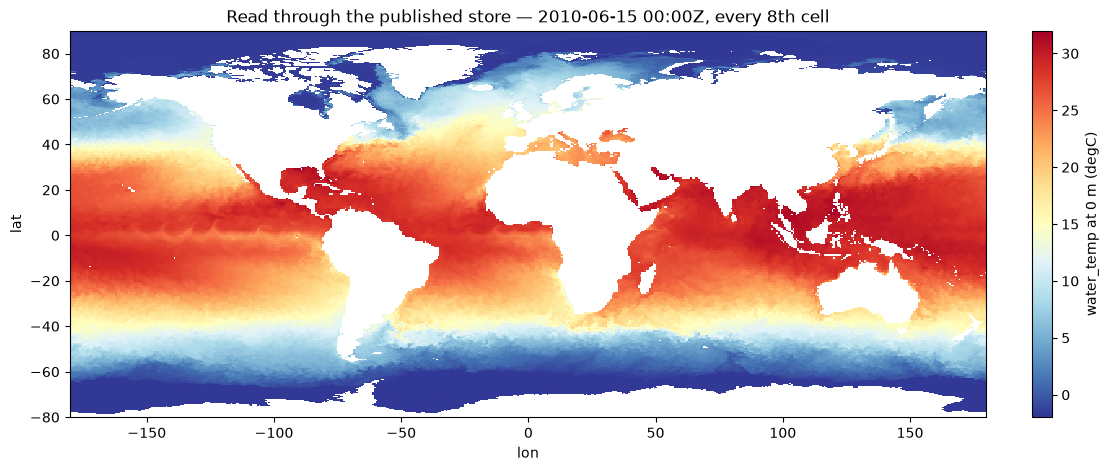

In [11]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(11, 4.6), constrained_layout=True)
m = ax.pcolormesh(sst.lon[::8], sst.lat[::8], sst.values[0, 0, ::8, ::8], cmap="RdYlBu_r", vmin=-2, vmax=32, shading="auto")
fig.colorbar(m, ax=ax, label="water_temp at 0 m (degC)")
ax.set(title=f"Read through the published store — {t}Z, every 8th cell", xlabel="lon", ylabel="lat")
plt.show()

## 7. Mirror the documentation beside the store

Source Cooperative serves the prefix as plain files, so this dataset's README, dependency
floors, code and two manifests go to `hycom/docs/hycom-gofs-3pt1-reanalysis/`, and the
collection's README and licence to `hycom/`, and the store is self-describing. Nothing is put
inside the Icechunk repository's own prefix.
Mirror from merged `main` only. Content types are set explicitly: Source Cooperative serves
them exactly as uploaded and never infers them.

In [12]:
TEXT, PY, NB = "text/plain; charset=utf-8", "text/x-python; charset=utf-8", "application/x-ipynb+json"
MIRROR = {   # local file -> (key on Source Cooperative, content type)
    "README.md":                    (f"{DOCS}/README.md", "text/markdown; charset=utf-8"),
    "requirements.txt":             (f"{DOCS}/requirements.txt", TEXT),
    "hycom_virtual.py":             (f"{DOCS}/hycom_virtual.py", PY),
    "../icechunk_utils.py":         (f"{DOCS}/icechunk_utils.py", PY),      # beside the notebook, so it imports
    "hycom-icechunk-sc.ipynb":      (f"{DOCS}/hycom-icechunk-sc.ipynb", NB),
    "hycom-smoke-test-local.ipynb": (f"{DOCS}/hycom-smoke-test-local.ipynb", NB),
    "missing-time-steps.csv":       (f"{DOCS}/missing-time-steps.csv", "text/csv; charset=utf-8"),
    "source-files.csv.gz":          (f"{DOCS}/source-files.csv.gz", "application/gzip"),
    "../README.md":                 (f"{ROOT}/README.md", "text/markdown; charset=utf-8"),   # the collection's README
    "../LICENSE":                   (f"{ROOT}/LICENSE", TEXT),
}
if RUN_MIRROR:
    import boto3
    from icechunk_utils import get_source_credentials
    c, _exp = get_source_credentials()
    s3 = boto3.client("s3", endpoint_url=c["endpoint_url"], region_name=c["region_name"], aws_access_key_id=c["aws_access_key_id"],
                      aws_secret_access_key=c["aws_secret_access_key"], aws_session_token=c["aws_session_token"])
    del c
    for name, (key, ctype) in MIRROR.items():
        assert Path(name).is_file(), name
        s3.upload_file(name, BUCKET, key, ExtraArgs={"ContentType": ctype})
        print(f"put {key}  ({ctype})")
else:
    print("RUN_MIRROR is False: nothing uploaded.")

RUN_MIRROR is False: nothing uploaded.
